Configuring GPU settings...
✓ GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

                           MOBILENET-UNET WITH ENCODER-ONLY ECA ATTENTION                           
Loading train data...
  train: 400 samples
Loading val data...
  val: 400 samples
Loading test data...
  test: 400 samples
Split - Train: 600, Val: 200, Test: 400

TRAINING: Deeper_Focal_EIoU_MC_ECA_EncoderOnly
  Focal-EIoU Loss: ✓
  Deeper Decoder: ✓
  MC Dropout: ✓ (rate=0.3)

Building Combined UNet with ENCODER-ONLY ECA...
  Deeper Architecture: True
  MC Dropout Rate: 0.3
  ECA Attention: ENCODER-ONLY (5 blocks on encoder outputs)
  Applying ECA to encoder outputs...
    encoder_1 (128x128, 96 channels): WITH ECA ✓ → flows to skip_1
    encoder_2 (64x64, 144 channels): WITH ECA ✓ → flows to skip_2
    encoder_3 (32x32, 192 channels): WITH ECA ✓ → flows to skip_3
    encoder_4 (16x16, 576 channels): WITH ECA ✓ → flows to skip_4
    bridge (8x8, 1280 channels): WITH ECA ✓

  MC

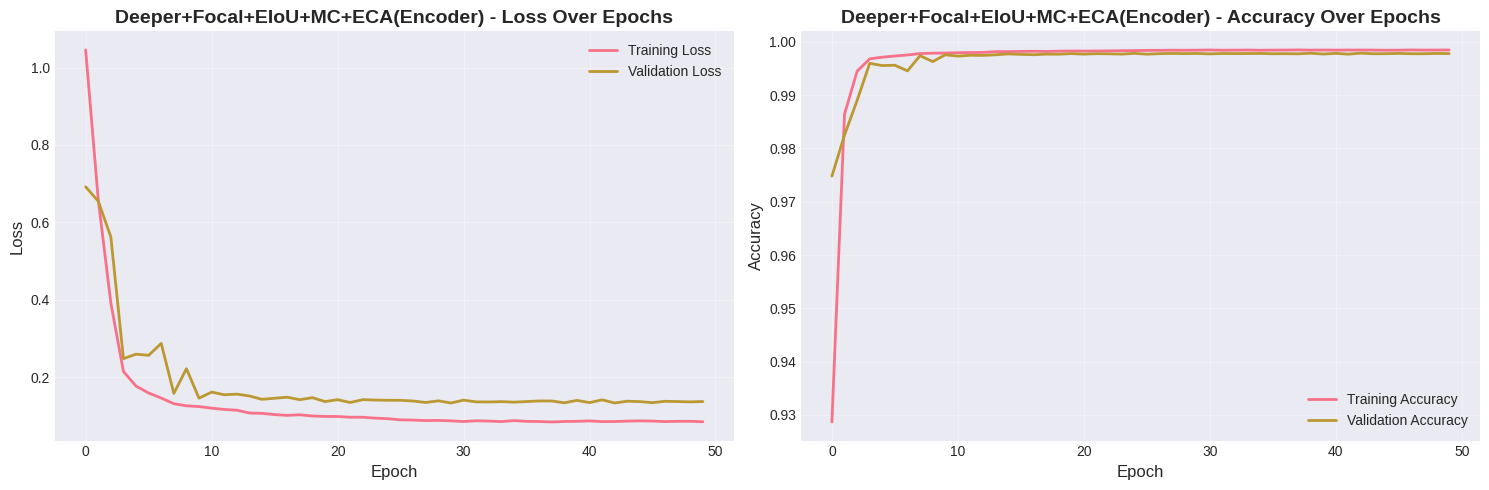

✓ Confusion matrices saved: results/Deeper+Focal+EIoU+MC+ECA(Encoder)_confusion_matrices.png


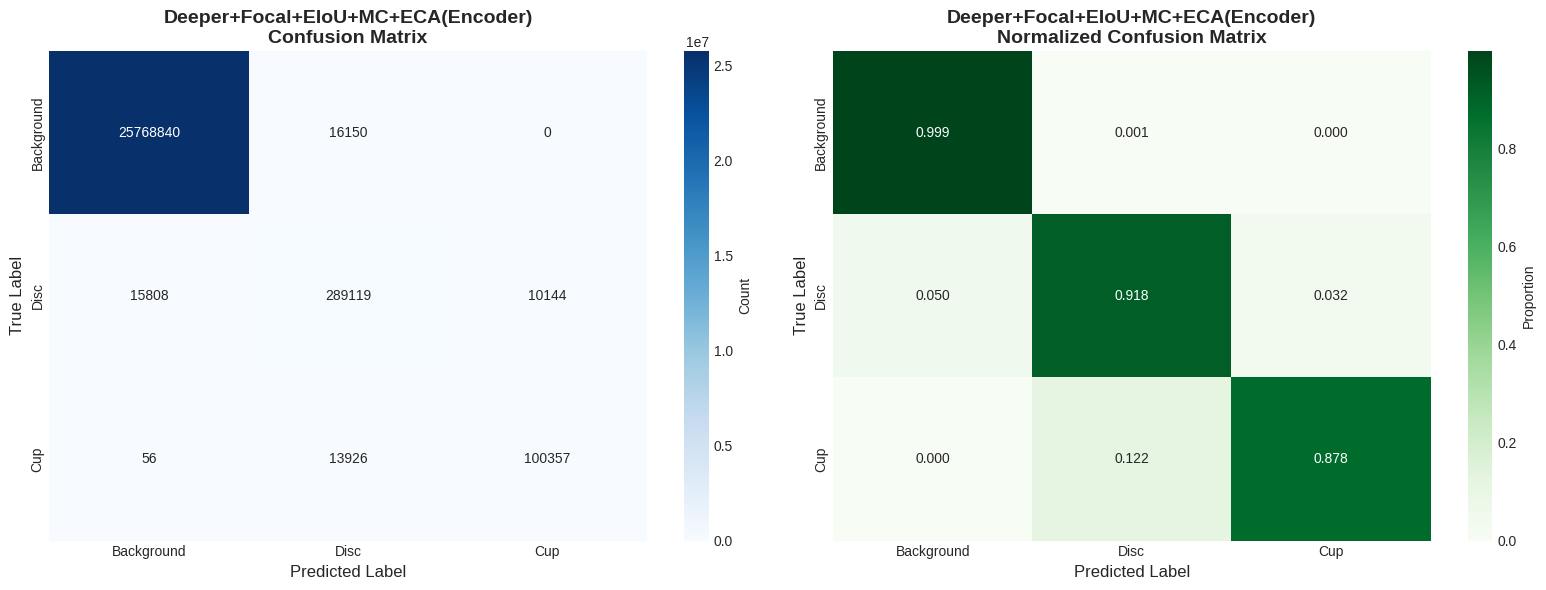


Confusion Matrix:
[[25768840    16150        0]
 [   15808   289119    10144]
 [      56    13926   100357]]

Normalized Confusion Matrix:
[[0.999 0.001 0.   ]
 [0.05  0.918 0.032]
 [0.    0.122 0.878]]

                                ✓ TRAINING AND EVALUATION COMPLETED!                                

Model: Deeper + Focal-EIoU + MC Dropout + ECA Attention (ENCODER-ONLY)
Attention: ECA on encoder outputs (5 blocks)
Parameters: 37,131,423
Results saved in: results/




In [5]:
"""
COMBINED ADVANCED MOBILENET-UNET WITH ENCODER-ONLY ECA ATTENTION
==================================================================
This combines:
1. Deeper decoder architecture with enhanced blocks
2. Focal-EIoU loss
3. MC Dropout for uncertainty estimation
4. ECA (Efficient Channel Attention) - ENCODER-ONLY VERSION
   - Applied ONLY to: Encoder outputs (4 locations + bridge)
   - REMOVED from: decoder blocks, final layer
   - Each encoder output gets attention ONCE, then flows to skip connections

STRATEGY: Place ECA after each encoder block to refine encoder features.
These refined features naturally flow to skip connections and next encoder layers
without double attention.
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import albumentations as A
import warnings
import gc
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for gpu in physical_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.set_visible_devices(physical_devices[0], 'GPU')
            print(f"✓ GPU found: {physical_devices}")
            return True
        except RuntimeError as e:
            print(f"✗ GPU configuration error: {e}")
            return False
    else:
        print("✗ No GPU found, using CPU")
        return False

def load_images_masks(images_folder, masks_folder, img_size=(256,256)):
    """Load images and masks from folders"""
    images, masks = [], []
    image_files = sorted(os.listdir(images_folder))
    mask_files = sorted(os.listdir(masks_folder))
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        if base in mask_dict:
            img = cv2.imread(os.path.join(images_folder, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size) / 255.0
            
            mask = cv2.imread(os.path.join(masks_folder, mask_dict[base]), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)
            unique_vals = np.unique(mask)
            if len(unique_vals) > 3 or np.max(unique_vals) > 2:
                mask = np.clip(mask // 85, 0, 2).astype(np.uint8)
            
            images.append(img)
            masks.append(mask)
    
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

def load_all_data(root_dir):
    """Load all data from existing splits and merge"""
    all_images, all_masks = [], []
    for split in ["train", "val", "test"]:
        print(f"Loading {split} data...")
        imgs, msks = load_images_masks(
            os.path.join(root_dir, split, "Images"),
            os.path.join(root_dir, split, "Masks")
        )
        all_images.append(imgs)
        all_masks.append(msks)
        print(f"  {split}: {imgs.shape[0]} samples")
    
    all_images = np.concatenate(all_images, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    return all_images, all_masks

def create_new_split(all_images, all_masks):
    """Create new split: 600 train, 200 val, 400 test"""
    X_temp, X_test, y_temp, y_test = train_test_split(
        all_images, all_masks, test_size=400, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=200, random_state=42
    )
    print(f"Split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def setup_augmentations():
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    ])

def data_generator(images, masks, batch_size, augment=None):
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                
                if augment:
                    aug = augment(image=img, mask=mask)
                    img_aug, mask_aug = aug['image'], aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                
                mask_cat = to_categorical(mask_aug, num_classes=3)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            
            yield np.stack(batch_x).astype(np.float32), np.stack(batch_y).astype(np.float32)

# ============================================================================
# ECA ATTENTION MODULE
# ============================================================================

def eca_block(input_feature, b=1, gamma=2, name=""):
    """
    ECA (Efficient Channel Attention) Module
    
    Unlike CBAM which uses both channel and spatial attention, ECA only uses
    efficient channel attention with adaptive kernel size.
    
    Args:
        input_feature: Input tensor
        b: Parameter for adaptive kernel size calculation (default: 1)
        gamma: Parameter for adaptive kernel size calculation (default: 2)
        name: Name prefix for layers
    
    Paper: "ECA-Net: Efficient Channel Attention for Deep Convolutional Neural Networks"
    """
    channel = input_feature.shape[-1]
    
    # Adaptive kernel size calculation
    # k = |log2(channel) / gamma + b / gamma|_odd
    t = int(abs((np.log2(channel) / gamma) + (b / gamma)))
    k = t if t % 2 else t + 1  # Make it odd
    k = max(3, k)  # Minimum kernel size of 3
    
    # Global Average Pooling
    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((channel, 1))(avg_pool)
    
    # 1D Convolution with adaptive kernel size
    # This is the key difference from CBAM - uses 1D conv instead of FC layers
    eca_feature = layers.Conv1D(
        filters=1,
        kernel_size=k,
        padding='same',
        activation='sigmoid',
        name=f'eca_conv1d_{name}'
    )(avg_pool)
    
    eca_feature = layers.Reshape((1, 1, channel))(eca_feature)
    
    # Multiply input with attention weights
    output = layers.Multiply(name=f'eca_multiply_{name}')([input_feature, eca_feature])
    
    return output

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    if alpha is None:
        alpha = [0.25, 1.0, 1.0]
    
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        pt = y_pred_c
        focal_weight = K.pow(1.0 - pt, gamma)
        cross_entropy = -K.log(pt)
        focal_loss_c = alpha[c] * focal_weight * cross_entropy * y_true_c
        focal_loss_value += K.mean(focal_loss_c)
    
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    eiou_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        
        height = K.cast(K.shape(y_true_c)[1], 'float32')
        width = K.cast(K.shape(y_true_c)[2], 'float32')
        
        y_coords = K.arange(0, height)
        x_coords = K.arange(0, width)
        y_grid = K.tile(K.reshape(y_coords, (-1, 1)), (1, K.cast(width, 'int32')))
        x_grid = K.tile(K.reshape(x_coords, (1, -1)), (K.cast(height, 'int32'), 1))
        y_grid = K.cast(y_grid, 'float32')
        x_grid = K.cast(x_grid, 'float32')
        
        true_mass = K.sum(y_true_c, axis=[1, 2]) + smooth
        true_center_y = K.sum(y_true_c * y_grid, axis=[1, 2]) / true_mass
        true_center_x = K.sum(y_true_c * x_grid, axis=[1, 2]) / true_mass
        
        pred_mass = K.sum(y_pred_c, axis=[1, 2]) + smooth
        pred_center_y = K.sum(y_pred_c * y_grid, axis=[1, 2]) / pred_mass
        pred_center_x = K.sum(y_pred_c * x_grid, axis=[1, 2]) / pred_mass
        
        center_distance = K.square(true_center_y - pred_center_y) + K.square(true_center_x - pred_center_x)
        diagonal = K.square(height) + K.square(width)
        center_penalty = center_distance / (diagonal + smooth)
        
        true_width = K.sqrt(K.sum(K.sum(y_true_c, axis=1), axis=1) + smooth)
        true_height = K.sqrt(K.sum(K.sum(y_true_c, axis=2), axis=1) + smooth)
        pred_width = K.sqrt(K.sum(K.sum(y_pred_c, axis=1), axis=1) + smooth)
        pred_height = K.sqrt(K.sum(K.sum(y_pred_c, axis=2), axis=1) + smooth)
        
        width_diff = K.square(pred_width - true_width)
        height_diff = K.square(pred_height - true_height)
        aspect_penalty = width_diff / (K.square(width) + smooth) + height_diff / (K.square(height) + smooth)
        
        eiou_c = 1.0 - iou + center_penalty + aspect_penalty
        eiou_loss_value += K.mean(eiou_c)
    
    return eiou_loss_value / 3.0

def focal_eiou_combined_loss(y_true, y_pred, focal_weight=1.0, eiou_weight=1.0, gamma=2.0, alpha=None):
    fl = focal_loss(y_true, y_pred, gamma=gamma, alpha=alpha)
    eiou = enhanced_iou_loss(y_true, y_pred)
    return focal_weight * fl + eiou_weight * eiou

# ============================================================================
# ENHANCED DECODER BLOCK (WITHOUT ECA - for encoder-only version)
# ============================================================================

def enhanced_decoder_block_no_eca(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """Enhanced decoder block WITHOUT ECA attention"""
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), activation='relu', 
                                      padding='same', name=f'{block_name}_skip_align')(skip_connection)
        skip_connection = layers.BatchNormalization(name=f'{block_name}_skip_bn')(skip_connection)
    
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    
    # NO ECA in decoder blocks for encoder-only version
    
    return x

# ============================================================================
# MODEL: ENCODER-ONLY ECA VERSION (5 blocks: 4 encoder outputs + bridge)
# ============================================================================

def build_combined_unet_encoder_only_eca(input_shape=(256, 256, 3), num_classes=3, 
                                          use_deeper=False, dropout_rate=0.3):
    """
    Combined MobileNet-UNet with ENCODER-ONLY ECA
    
    ECA Placement (ENCODER-ONLY VERSION):
    - Encoder_1 output (128x128): YES ✅ (then flows to skip_1)
    - Encoder_2 output (64x64): YES ✅ (then flows to skip_2)
    - Encoder_3 output (32x32): YES ✅ (then flows to skip_3)
    - Encoder_4 output (16x16): YES ✅ (then flows to skip_4)
    - Bridge output (8x8): YES ✅
    - Decoder blocks: NO ECA ❌
    - Final layer: NO ECA ❌
    Total: 5 ECA blocks (on encoder outputs only)
    
    Rationale: Apply attention once to each encoder output. The refined features
    naturally flow to skip connections without double attention.
    """
    
    print(f"\nBuilding Combined UNet with ENCODER-ONLY ECA...")
    print(f"  Deeper Architecture: {use_deeper}")
    print(f"  MC Dropout Rate: {dropout_rate}")
    print(f"  ECA Attention: ENCODER-ONLY (5 blocks on encoder outputs)")
    
    inputs = layers.Input(input_shape, dtype='float32')
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    
    # Get encoder outputs (RAW, before ECA)
    enc_1_raw = backbone.get_layer('block_1_expand_relu').output  # 128x128
    enc_2_raw = backbone.get_layer('block_3_expand_relu').output  # 64x64
    enc_3_raw = backbone.get_layer('block_6_expand_relu').output  # 32x32
    enc_4_raw = backbone.get_layer('block_13_expand_relu').output # 16x16
    bridge_raw = backbone.output  # 8x8
    
    print("  Applying ECA to encoder outputs...")
    print(f"    encoder_1 (128x128, {enc_1_raw.shape[-1]} channels): WITH ECA ✓ → flows to skip_1")
    print(f"    encoder_2 (64x64, {enc_2_raw.shape[-1]} channels): WITH ECA ✓ → flows to skip_2")
    print(f"    encoder_3 (32x32, {enc_3_raw.shape[-1]} channels): WITH ECA ✓ → flows to skip_3")
    print(f"    encoder_4 (16x16, {enc_4_raw.shape[-1]} channels): WITH ECA ✓ → flows to skip_4")
    print(f"    bridge (8x8, {bridge_raw.shape[-1]} channels): WITH ECA ✓")
    
    # Apply ECA to ALL encoder outputs (these become the skip connections)
    skip_1 = eca_block(enc_1_raw, name="enc1")
    skip_2 = eca_block(enc_2_raw, name="enc2")
    skip_3 = eca_block(enc_3_raw, name="enc3")
    skip_4 = eca_block(enc_4_raw, name="enc4")
    bridge = eca_block(bridge_raw, name="bridge")
    
    # Deeper bridge (if enabled) - applied AFTER ECA
    if use_deeper:
        bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
        bridge = layers.BatchNormalization()(bridge)
    
    if dropout_rate > 0:
        bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    
    if use_deeper:
        x = enhanced_decoder_block_no_eca(bridge, skip_4, 512, 'decoder_1', dropout_rate)
        x = enhanced_decoder_block_no_eca(x, skip_3, 256, 'decoder_2', dropout_rate)
        x = enhanced_decoder_block_no_eca(x, skip_2, 128, 'decoder_3', dropout_rate * 0.7)
        x = enhanced_decoder_block_no_eca(x, skip_1, 64, 'decoder_4', dropout_rate * 0.5)
    else:
        # Baseline decoder without ECA
        x = layers.UpSampling2D((2, 2))(bridge)
        x = layers.Concatenate()([x, skip_4])
        x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip_3])
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip_2])
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate * 0.7)(x)
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Concatenate()([x, skip_1])
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate * 0.5)(x)
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
    
    # Final upsampling - NO ECA
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    
    model = models.Model(inputs, outputs)
    
    # Print configuration
    if dropout_rate > 0:
        dropout_layers = [layer for layer in model.layers if isinstance(layer, layers.Dropout)]
        print(f"\n  MC Dropout Configuration:")
        print(f"    Total Dropout Layers: {len(dropout_layers)}")
        print(f"    Dropout Rates: {[f'{layer.rate:.2f}' for layer in dropout_layers]}")
    
    eca_count = sum(1 for layer in model.layers if 'eca_conv1d' in layer.name)
    print(f"\n  ECA Configuration (ENCODER-ONLY):")
    print(f"    Total ECA Blocks: {eca_count}")
    print(f"    ECA Locations: Encoder outputs ONLY (5 blocks)")
    print(f"    Removed ECA from: Decoder blocks, Final layer")
    print(f"    Note: Each encoder output gets ECA once, then flows to skip connection")
    
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

# ============================================================================
# MC DROPOUT
# ============================================================================

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    """MC Dropout prediction using training=True flag"""
    if verbose:
        print(f"\nRunning MC Dropout with {num_samples} stochastic forward passes...")
    
    predictions = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    for i in range(num_samples):
        if verbose and (i + 1) % 5 == 0:
            print(f"  Completed: {i+1}/{num_samples} forward passes")
        
        batch_preds = []
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(X))
            X_batch = X[start_idx:end_idx]
            
            pred_batch = model(X_batch, training=True)
            batch_preds.append(pred_batch.numpy())
        
        pred = np.concatenate(batch_preds, axis=0)
        predictions.append(pred)
        
        if (i + 1) % 5 == 0:
            gc.collect()
    
    all_preds = np.array(predictions)
    mean_pred = np.mean(all_preds, axis=0)
    std_pred = np.std(all_preds, axis=0)
    
    del all_preds
    gc.collect()
    
    if verbose:
        print(f"✓ MC Dropout completed")
    
    return mean_pred, std_pred

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_training_history(history, model_name, save_dir='results'):
    """Plot training history: loss and accuracy curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_training_curves.png", dpi=300, bbox_inches='tight')
    print(f"✓ Training curves saved: {save_dir}/{model_name}_training_curves.png")
    plt.show()
    plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    """Plot confusion matrix and normalized confusion matrix"""
    y_true_labels = np.argmax(y_true, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    class_names = ['Background', 'Disc', 'Cup']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name}\nNormalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"✓ Confusion matrices saved: {save_dir}/{model_name}_confusion_matrices.png")
    plt.show()
    plt.close()
    
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nNormalized Confusion Matrix:\n{np.round(cm_normalized, 3)}")
    
    return cm, cm_normalized

# ============================================================================
# TRAINING
# ============================================================================

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, model_name, 
               use_focal_eiou=False, use_deeper=False, dropout_rate=0.0,
               augment=None, save_dir='results'):
    """Train model with visualization"""
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Focal-EIoU Loss: {'✓' if use_focal_eiou else '✗'}")
    print(f"  Deeper Decoder: {'✓' if use_deeper else '✗'}")
    print(f"  MC Dropout: {'✓ (rate=' + str(dropout_rate) + ')' if dropout_rate > 0 else '✗'}")
    
    K.clear_session()
    
    # Build model
    model = build_combined_unet_encoder_only_eca(use_deeper=use_deeper, dropout_rate=dropout_rate)
    param_count = model.count_params()
    print(f"  Total Parameters: {param_count:,}")
    
    # Choose loss
    if use_focal_eiou:
        loss_fn = focal_eiou_combined_loss
    else:
        loss_fn = "categorical_crossentropy"
    
    # Compile
    initial_lr = 5e-4 if use_deeper else 1e-3
    model.compile(
        optimizer=optimizers.Adam(learning_rate=initial_lr),
        loss=loss_fn,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2]
    )
    
    # Callbacks
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True, 
                                verbose=1, monitor='val_loss', mode='min')
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, 
                                  verbose=1, mode='min', min_lr=1e-7)
    early_stop = EarlyStopping(monitor="val_loss", patience=20, verbose=1, 
                              restore_best_weights=True, mode='min')
    
    # Training
    batch_size = 4 if use_deeper else 8
    steps_train = X_train.shape[0] // batch_size
    steps_val = X_val.shape[0] // batch_size
    
    try:
        history = model.fit(
            data_generator(X_train, y_train, batch_size, augment),
            validation_data=data_generator(X_val, y_val, batch_size, None),
            steps_per_epoch=steps_train,
            validation_steps=steps_val,
            epochs=50,
            callbacks=[checkpoint, reduce_lr, early_stop],
            verbose=1
        )
    except Exception as e:
        print(f"✗ Error: {e}. Retrying with smaller batch...")
        batch_size = 2 if use_deeper else 4
        steps_train = X_train.shape[0] // batch_size
        steps_val = X_val.shape[0] // batch_size
        
        history = model.fit(
            data_generator(X_train, y_train, batch_size, augment),
            validation_data=data_generator(X_val, y_val, batch_size, None),
            steps_per_epoch=steps_train,
            validation_steps=steps_val,
            epochs=50,
            callbacks=[checkpoint, reduce_lr, early_stop],
            verbose=1
        )
    
    print(f"✓ Training completed")
    
    return model, history, param_count

# ============================================================================
# EVALUATION
# ============================================================================

def evaluate_model(model, X_test, y_test, model_name, run_mc_dropout=False, history=None, save_dir='results'):
    """Evaluate model"""
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    
    y_test_cat = np.array([to_categorical(mask, num_classes=3) for mask in y_test])
    
    # Predict
    y_pred = model.predict(X_test, verbose=0, batch_size=8)
    
    # Classification metrics
    y_true_labels = np.argmax(y_test_cat, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    precision = precision_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    
    print(f"\nPrecision, Recall, F1 Score per class:")
    class_names = ["Background", "Disc", "Cup"]
    for idx, cname in enumerate(class_names):
        print(f"  {cname}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}")
    
    print(f"\nMacro-averaged metrics:")
    print(f"  Precision: {np.mean(precision):.4f}")
    print(f"  Recall: {np.mean(recall):.4f}")
    print(f"  F1 Score: {np.mean(f1):.4f}")
    
    # Per-class Dice and IoU
    results = {'standard': {}}
    for cidx, cname in enumerate(class_names):
        y_true_c = (np.argmax(y_test_cat, axis=-1) == cidx).astype(np.float32)
        y_pred_c = (np.argmax(y_pred, axis=-1) == cidx).astype(np.float32)
        
        intersection = np.sum(y_true_c * y_pred_c)
        dice = (2. * intersection + 1e-7) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
        union = np.sum(y_true_c) + np.sum(y_pred_c) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        results['standard'][cname] = {'dice': dice, 'iou': iou}
        print(f"  {cname}: Dice={dice:.4f}, IoU={iou:.4f}")
    
    # MC Dropout
    if run_mc_dropout:
        print("\nMC Dropout Evaluation:")
        mean_pred, std_pred = mc_dropout_predict(model, X_test[:100], num_samples=10, verbose=True)
        results['mc_dropout'] = {}
        for cidx, cname in enumerate(class_names):
            mean_std = np.mean(std_pred[:, :, :, cidx])
            results['mc_dropout'][cname] = {'mean_uncertainty': mean_std}
            print(f"  {cname} uncertainty: {mean_std:.4f}")
    
    # Generate visualizations AFTER printing all metrics
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    
    if history is not None:
        plot_training_history(history, model_name, save_dir)
    
    plot_confusion_matrices(y_test_cat, y_pred, model_name, save_dir=save_dir)
    
    return results

# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/refuge/REFUGE/"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*100}")
    print(f"{'MOBILENET-UNET WITH ENCODER-ONLY ECA ATTENTION':^100s}")
    print(f"{'='*100}")
    
    # Load data
    all_images, all_masks = load_all_data(root_dir)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = create_new_split(all_images, all_masks)
    
    # Train model with ECA
    model, history, params = train_model(
        X_train, y_train, X_val, y_val, X_test, y_test,
        "Deeper_Focal_EIoU_MC_ECA_EncoderOnly",
        use_focal_eiou=True, use_deeper=True, dropout_rate=0.3,
        augment=train_aug, save_dir=save_dir
    )
    
    # Evaluate
    results = evaluate_model(model, X_test, y_test, "Deeper+Focal+EIoU+MC+ECA(Encoder)", 
                            run_mc_dropout=True, history=history, save_dir=save_dir)
    
    print(f"\n{'='*100}")
    print(f"{'✓ TRAINING AND EVALUATION COMPLETED!':^100s}")
    print(f"{'='*100}")
    print(f"\nModel: Deeper + Focal-EIoU + MC Dropout + ECA Attention (ENCODER-ONLY)")
    print(f"Attention: ECA on encoder outputs (5 blocks)")
    print(f"Parameters: {params:,}")
    print(f"Results saved in: {save_dir}/")
    print(f"\n{'='*100}\n")